# K562 cell-line overlap between Repli Hi-C and Hi-C

In [1]:
import sys
sys.path.append('..')
from utils.plotting import plot_hic, plot_n_hic, genomic_labels, format_ticks

from notebooks.func_analysis import *
from notebooks.func_plotting import *
from notebooks.func_iou import *
from notebooks.func_pileup import *

import os
import itertools
import pybedtools
from matplotlib_venn import venn2
from collections import defaultdict
from pyBedGraph import BedGraph
import subprocess
import yaml


from io import StringIO

## Start

In [2]:
# Analysis parameters
save_path = "/nfs/turbo/umms-minjilab/sionkim/miajet_analysis"
result_type = "saliency-90-p-0.1" # MIA-Jet

# Pileup parameters
data_type = "oe"
expected_stack_size = 100

# Overlap parameters
iou_threshold = 0  # ANY overlap

insituhic_file = "/nfs/turbo/umms-minjilab/downloaded_data/K562_hic_Rao-2014_ENCFF616PUW_hg38.hic" # hg38
intacthic_file = "/nfs/turbo/umms-minjilab/downloaded_data/K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38.hic" # hg38
replihic_file = "/nfs/turbo/umms-minjilab/downloaded_data/Repli-HiC_K562_WT_totalS.hic" # hg19

data_name = "K562 cell-line"

resolution = 50000 # 50Kb resolution
normalization = "VC_SQRT"

# Overlap parameter is relative to resolution
buffer_radius = 3 * resolution  

# FUN
f_pred_fun_replihic_bedpe = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FUN_Repli-HiC_K562_WT_totalS/FUN-pred_50000_1.3.bedpe"
f_pred_fun_replihic_tab = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FUN_Repli-HiC_K562_WT_totalS/FUN-pred_50000_1.3.tab"

f_pred_fun_insituhic_bedpe = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FUN_K562_hic_Rao-2014_ENCFF616PUW_hg38/FUN-pred_50000_1.3.bedpe"
f_pred_fun_insituhic_tab = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FUN_K562_hic_Rao-2014_ENCFF616PUW_hg38/FUN-pred_50000_1.3.tab"

f_pred_fun_intacthic_bedpe = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FUN_K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38/FUN-pred_50000_1.3.bedpe"
f_pred_fun_intacthic_tab = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FUN_K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38/FUN-pred_50000_1.3.tab"

# FONTANKA
# for Repli Hi-C use weak thresholded
f_pred_fontanka_replihic = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FONTANKA_Repli-HiC_K562_WT_totalS.50000.predicted.fountains.thresholded-weak.tsv" 
f_pred_fontanka_insituhic = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FONTANKA_K562_hic_Rao-2014_ENCFF616PUW_hg38.50000.predicted.fountains.thresholded-weak.tsv"
f_pred_fontanka_intacthic = f"/nfs/turbo/umms-minjilab/sionkim/jet_pred/FONTANKA_K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38.50000.predicted.fountains.thresholded-weak.tsv"

# MIA-JET
f_pred_miajet_replihic_summary = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/Repli-HiC_K562_WT_totalS_chr_combined_{genomic_labels(resolution)}/Repli-HiC_K562_WT_totalS_chr_combined_{result_type}_{genomic_labels(resolution)}_summary_table.csv"
f_pred_miajet_replihic_expanded = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/Repli-HiC_K562_WT_totalS_chr_combined_{genomic_labels(resolution)}/Repli-HiC_K562_WT_totalS_chr_combined_{result_type}_{genomic_labels(resolution)}_expanded_table.csv"

f_pred_miajet_insituhic_summary = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/K562_hic_Rao-2014_ENCFF616PUW_hg38_chr_combined_{genomic_labels(resolution)}/K562_hic_Rao-2014_ENCFF616PUW_hg38_chr_combined_{result_type}_{genomic_labels(resolution)}_summary_table.csv"
f_pred_miajet_insituhic_expanded = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/K562_hic_Rao-2014_ENCFF616PUW_hg38_chr_combined_{genomic_labels(resolution)}/K562_hic_Rao-2014_ENCFF616PUW_hg38_chr_combined_{result_type}_{genomic_labels(resolution)}_expanded_table.csv"

f_pred_miajet_intacthic_summary = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38_chr_combined_{genomic_labels(resolution)}/K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38_chr_combined_{result_type}_{genomic_labels(resolution)}_summary_table.csv"
f_pred_miajet_intacthic_expanded = f"/nfs/turbo/umms-minjilab/sionkim/miajet_output/K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38_chr_combined_{genomic_labels(resolution)}/K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38_chr_combined_{result_type}_{genomic_labels(resolution)}_expanded_table.csv"   

names = [
    "Repli-HiC_K562_WT_totalS (hg19)",
    "In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38",
    "Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38"
]

genomes = [
    "hg19",
    "hg38",
    "hg38"
]

fun_bedpe_list = [
    f_pred_fun_replihic_bedpe,
    f_pred_fun_insituhic_bedpe,
    f_pred_fun_intacthic_bedpe
]

fun_table_list = [
    f_pred_fun_replihic_tab,
    f_pred_fun_insituhic_tab,
    f_pred_fun_intacthic_tab
]

fontanka_table_list = [ 
    f_pred_fontanka_replihic,
    f_pred_fontanka_insituhic,
    f_pred_fontanka_intacthic
]

miajet_table_list = [
    f_pred_miajet_replihic_summary,
    f_pred_miajet_insituhic_summary,
    f_pred_miajet_intacthic_summary
]

miajet_position_list = [
    f_pred_miajet_replihic_expanded,
    f_pred_miajet_insituhic_expanded,
    f_pred_miajet_intacthic_expanded
]

In [3]:
chrom_sizes = bf.fetch_chromsizes("hg19", as_bed=True)
common_chroms = chrom_sizes['chrom'].tolist()
print(common_chroms) # Should be same for hg38

['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22', 'chrX', 'chrY', 'chrM']


In [4]:
# Choose jet caller method
select_method_idx = 0
method_names = [f"MIA-Jet {result_type}", "Fun", "Fontanka"]
ranking_col = ["jet_saliency", "SoN", "FS_peaks"]

selected_method = method_names[select_method_idx]
data_name += f" ({selected_method})"

tables = []
positions = []

# Process all at once
for i in range(len(names)):
    name = names[i]

    f_fun_bedpe = fun_bedpe_list[i]
    f_fun_table = fun_table_list[i]
    f_fontanka_table = fontanka_table_list[i]
    f_miajet_table = miajet_table_list[i]
    f_miajet_position = miajet_position_list[i]

    # Load it in
    fun_bedpe = pd.read_csv(f_fun_bedpe, sep="\t")
    fun_table = pd.read_csv(f_fun_table, sep="\t")

    fontanka_table = pd.read_csv(f_fontanka_table, sep="\t", index_col=0)
    fontanka_table.dropna(inplace=True, how="any")
    fontanka_table.reset_index(inplace=True, drop=True)

    miajet_positions = pd.read_csv(f_miajet_position, comment="#")
    miajet_table = pd.read_csv(f_miajet_table, comment="#")

    # Process FUN
    fun_bedpe["extrusion_x"] = (fun_bedpe["y1"] + fun_bedpe["y2"]) / 2
    fun_bedpe["extrusion_y"] = (fun_bedpe["x1"] + fun_bedpe["x2"]) / 2
    assert np.all(fun_bedpe["extrusion_x"] >= fun_bedpe["extrusion_y"])

    fun_table["root"] = (fun_table["start"] + fun_table["end"]) / 2
    fun_table["unique_id"] = fun_table.index


    fun_minimal = fun_bedpe.copy()
    fun_minimal["root"] = fun_table["root"]

    fun_minimal["unique_id"] = fun_minimal.index
    fun_minimal["chrom"] = fun_table["chrom"]

    fun_minimal = fun_minimal[["unique_id", "chrom", "root", "extrusion_x", "extrusion_y"]]

    fun_positions = generate_positions(fun_minimal, resolution)
    fun_positions["unique_id"] = fun_positions["unique_id"].astype(int)

    lengths = fun_positions.groupby('unique_id').apply(lambda x : compute_length(x, p=2), include_groups=False)
    fun_table["length"] = lengths

    # Process FONTANKA
    fontanka_table = fontanka_table.reset_index(drop=True)
    fontanka_table["root"] = (fontanka_table["end"] + fontanka_table["start"]) / 2
    fontanka_table["unique_id"] = fontanka_table.index
    fontanka_table["extrusion_x"] = fontanka_table["window_end"]
    fontanka_table["extrusion_y"] = fontanka_table["window_start"]
    assert np.all(fontanka_table["extrusion_x"] >= fontanka_table["extrusion_y"])

    fontanka_table["length"] = -1

    fontanka_minimal = fontanka_table.copy()
    fontanka_minimal = fontanka_minimal[["unique_id", "chrom", "root", "extrusion_x", "extrusion_y"]]

    fontanka_positions = generate_positions(fontanka_minimal, resolution)
    fontanka_positions["unique_id"] = fontanka_positions["unique_id"].astype(int)    

    if select_method_idx == 0:
        tables.append(miajet_table)
        positions.append(miajet_positions)
    elif select_method_idx == 1:
        tables.append(fun_table)
        positions.append(fun_positions)
    elif select_method_idx == 2:
        tables.append(fontanka_table)
        positions.append(fontanka_positions)

In [5]:
# The 3 objects that Venn Diagram notebook uses
# We make a new object for proper Hi-C read-in
hic_file = [replihic_file, insituhic_file, intacthic_file]
names_abbrev = ["Repli Hi-C", "In situ Hi-C", "Intact Hi-C"]
names

['Repli-HiC_K562_WT_totalS (hg19)',
 'In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38',
 'Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38']

In [6]:
tables[0]

,unique_id,chrom,start,end,length,input_mean,angle_mean,width_mean,jet_saliency,ks,p-val_raw,p-val_corr,stripiness
0,chr1_514_9,chr1,8.523619e+07,8.608278e+07,1400000,0.085,90.625,4.303,0.099,0.643,0.000,0.000,-0.000
1,chr1_249_6,chr1,1.199737e+08,1.204153e+08,2750000,0.168,128.554,3.960,0.099,0.600,0.000,0.000,0.000
2,chr1_13648_2,chr1,1.879501e+07,1.894902e+07,250000,0.656,89.254,0.000,0.099,1.000,0.004,0.009,0.000
3,chr1_2659_9,chr1,7.551659e+06,7.799204e+06,400000,0.419,95.346,6.150,0.137,1.000,0.000,0.001,0.001
4,chr1_366_10,chr1,2.278907e+08,2.283309e+08,750000,0.229,85.123,7.548,0.136,0.533,0.013,0.021,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,chrX_272_5,chrX,3.624576e+07,3.678132e+07,850000,0.168,92.558,2.738,0.125,0.588,0.002,0.010,-0.001
1734,chrX_10_18,chrX,2.162268e+07,2.218963e+07,800000,0.304,89.468,8.452,0.125,0.875,0.000,0.000,0.002
1735,chrX_126_0,chrX,1.218737e+08,1.222388e+08,650000,0.296,93.528,1.989,0.163,0.923,0.000,0.000,0.002
1736,chrX_3105_7,chrX,2.494730e+07,2.536920e+07,600000,0.116,87.636,4.266,0.122,0.667,0.004,0.010,-0.000


In [7]:
positions[0]

,unique_id,chrom,x (bp),y (bp),x (pixels),y (pixels),width,angle_imagej,ridge_strength
0,chr1_2_17,chr1,5.093688e+07,4.838587e+07,1405.050,48.069,10.260,89.109,0.037
1,chr1_2_17,chr1,5.097384e+07,4.835287e+07,1405.106,47.080,10.248,88.782,0.036
2,chr1_2_17,chr1,5.101134e+07,4.832050e+07,1405.179,46.091,10.256,88.439,0.035
3,chr1_2_17,chr1,5.105856e+07,4.829502e+07,1405.486,45.063,10.176,86.725,0.034
4,chr1_2_17,chr1,5.109769e+07,4.826434e+07,1405.606,44.076,10.093,86.288,0.034
...,...,...,...,...,...,...,...,...,...
35148,chrX_1791_2,chrX,3.894247e+07,3.751328e+07,1081.662,63.934,2.439,85.227,0.017
35149,chrX_33_11,chrX,8.068244e+06,6.004175e+06,199.428,54.955,1.530,126.605,0.020
35150,chrX_33_11,chrX,7.279487e+06,5.213836e+06,177.096,54.933,1.437,75.972,0.012
35151,chrX_33_11,chrX,8.064296e+06,5.972081e+06,198.919,54.557,0.950,129.063,0.019


In [8]:
position_dict = dict(zip(names, positions))
table_dict = dict(zip(names, tables)) 

bed_tables = []
for i, (s, e) in enumerate(zip(tables, positions)):
    # bed_tables.append(generate_bed_df(s, e, eps=500e3, fraction=0.5))
    bed_tables.append(generate_bed_2(s, e, eps=500e3, fraction=1.5))

In [9]:
# PLOT LENGTH DISTRIBUTION OF ALL CALLED

lengths_list = []
titles = []
for i, s in enumerate(tables):

    lengths = s["length"].values

    if lengths[0] == -1:
        print(f"Lengths for {names[i]} are not available, skipping length histogram.")
        continue

    lengths_list.append(lengths)
    titles.append(f"{names[i]} distribution of jet lengths")


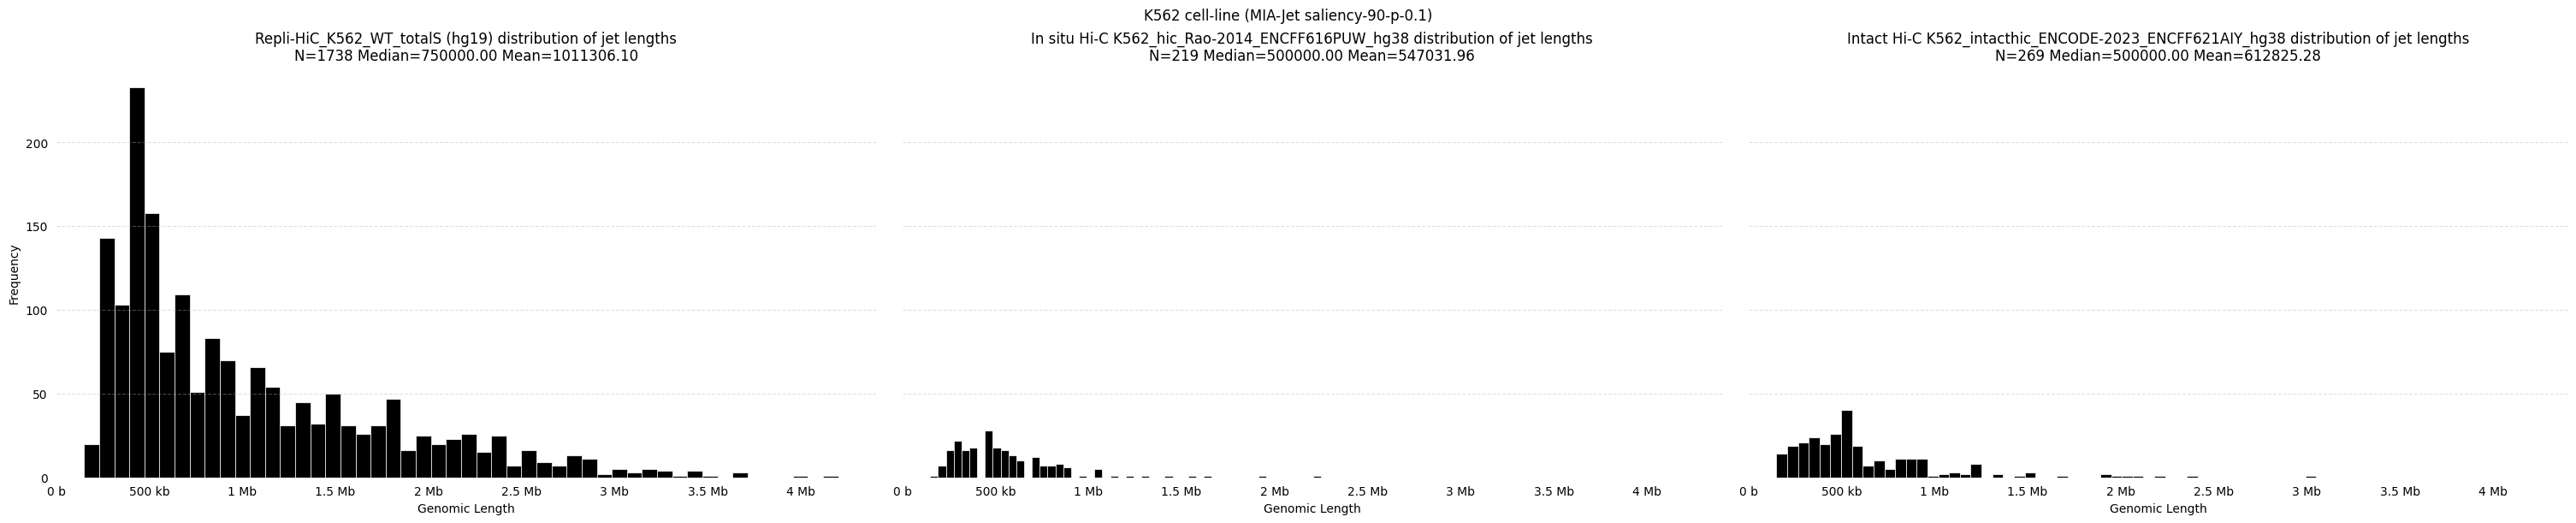

In [10]:
plot_n_length_histograms(lengths_list, titles=titles, suptitle=data_name, show=True, 
                         sharey=True,
                         save_name=f"{save_path}/{data_name}_length_distribution_sharey.png")

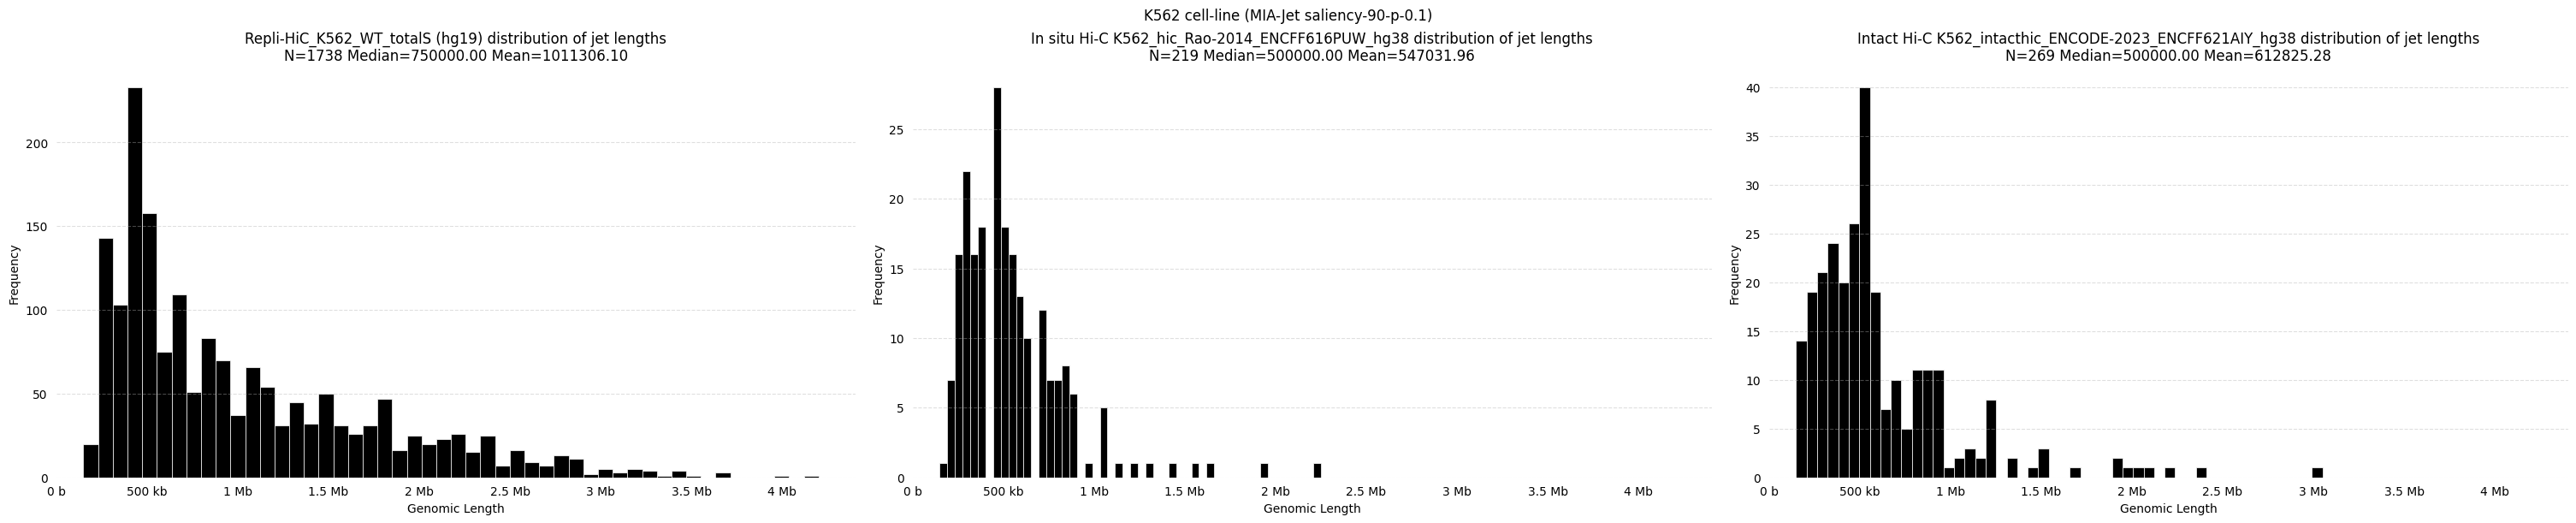

In [11]:
plot_n_length_histograms(lengths_list, titles=titles, suptitle=data_name, show=True, 
                         sharey=False,
                         save_name=f"{save_path}/{data_name}_length_distribution.png")

In [12]:
# PLOT ALL CALLED
agg_map = []
vmaxes = []
stacks = []
df_stack = []
resolutions = []
chipseq_stacks = []
# for each 

# resolutions = []
for idx, bed_df in enumerate(bed_tables):
    # Get pileups for each bed_df
    s, d, r = get_pileups_dynamic_resolution(
        hic_file=hic_file[idx],
        bed_df_in=bed_df,
        expected_stack_size=expected_stack_size,
        chrom_sizes=chrom_sizes,
        chromosomes='all',
        window_range=(None, None),
        data_type=data_type,
        normalization=normalization,
        sort=True,
        verbose=True
    )

    # Remove centromeres and resize square stacks
    s, d = remove_and_resize_square_stacks(s, d, expected_stack_size)

    if data_type == "observed":
        s = np.log10(s + 1) # log transform for visualization

    a = np.mean(s, axis=0)
    vmaxes.append(np.percentile(a, 99))  # store the 99th percentile for color scaling
    agg_map.append(a)  # average over all stacks
    stacks.append(s)  # store the stacks for later use
    df_stack.append(d)  # store the DataFrame for later use
    resolutions.append(r)  # store the resolution for later use

Retrieving pileups: 100%|██████████| 269/269 [00:20<00:00, 12.94it/s]


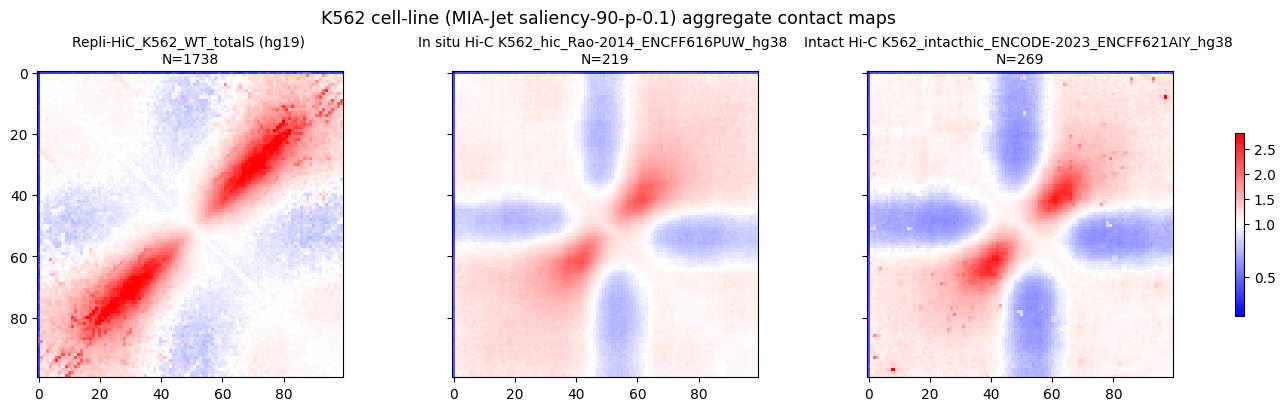

In [13]:
titles = [f"{names[i]} \nN={len(df_stack[i])}" for i in range(len(names))]

plot_n_hic(
    agg_map,
    suptitle=f"{data_name} aggregate contact maps",
    resolution=None,
    cmap_label=None,
    titles=titles,
    cmap='bwr',
    vcenter=1,
    standardize_cbar=True,
    show=True, 
    vmax=vmaxes,
    ppr=4,
    savepath=f"{save_path}/{data_name}_all_agg_map-{data_type}.png"
)

In [14]:
# # PLOT DIAGNOSTIC OF TOP N

# for idx in range(len(names)):
    
#     suptitle = names[idx]

#     # Select top jets according to "jet_saliency" column
#     top_n = 42  
#     # 1) get the original row‐indices of the top N
#     top_idx = df_stack[idx].nlargest(top_n, ranking_col[select_method_idx]).index

#     # 2) subset the DataFrame (and only then reset if you like)
#     sampled_df_stack = df_stack[idx].loc[top_idx].reset_index(drop=True)

#     # 3) subset the array with those SAME indices
#     sampled_stack = stacks[idx][top_idx]

#     titles = sampled_df_stack["chrom"].astype(str) + ":" + sampled_df_stack["start"].apply(lambda x : genomic_labels(x, N=1)) + "-" + sampled_df_stack["end"].apply(lambda x : genomic_labels(x, N=1))
#     titles += f" ({ranking_col[select_method_idx]}: " + sampled_df_stack[ranking_col[select_method_idx]].map(lambda x : f"{x:.3g}") + ")"
#     titles += f"\nResolution: " + pd.Series([genomic_labels(r, N=1) for r in resolutions[idx]]).astype(str) 
#     titles = titles.tolist()

#     genomic_shift = sampled_df_stack["start"].to_numpy()

#     vmaxes = [np.percentile(s, 99) for s in sampled_stack]

#     plot_n_hic(sampled_stack, 
#             titles=titles, 
#             resolution=resolutions[idx],
#             suptitle=f"{suptitle} N={top_n}\n{data_type} {normalization}", 
#             show=True, 
#             genomic_shift=genomic_shift, 
#             cmap_label=None, 
#             vmax=vmaxes,
#             ppr=6,
#             savepath=f"{save_path}/{data_name}_individual-topN_{data_type}_{names[idx]}_{ranking_col[select_method_idx]}.png",
#             cmap="Reds")

## Intersection

In [15]:
bed_tables[0]

,unique_id,chrom,length,input_mean,angle_mean,width_mean,jet_saliency,ks,p-val_raw,p-val_corr,stripiness,start,end
0,chr1_514_9,chr1,1400000,0.085,90.625,4.303,0.099,0.643,0.000,0.000,-0.000,8.081521e+07,8.719032e+07
1,chr1_249_6,chr1,2750000,0.168,128.554,3.960,0.099,0.600,0.000,0.000,0.000,1.150010e+08,1.235833e+08
2,chr1_13648_2,chr1,250000,0.656,89.254,0.000,0.099,1.000,0.004,0.009,0.000,1.790116e+07,1.952602e+07
3,chr1_2659_9,chr1,400000,0.419,95.346,6.150,0.137,1.000,0.000,0.001,0.001,6.228014e+06,8.422977e+06
4,chr1_366_10,chr1,750000,0.229,85.123,7.548,0.136,0.533,0.013,0.021,0.000,2.257066e+08,2.292002e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,chrX_272_5,chrX,850000,0.168,92.558,2.738,0.125,0.588,0.002,0.010,-0.001,3.393410e+07,3.761623e+07
1734,chrX_10_18,chrX,800000,0.304,89.468,8.452,0.125,0.875,0.000,0.000,0.002,1.954146e+07,2.297311e+07
1735,chrX_126_0,chrX,650000,0.296,93.528,1.989,0.163,0.923,0.000,0.000,0.002,1.199996e+08,1.230658e+08
1736,chrX_3105_7,chrX,600000,0.116,87.636,4.266,0.122,0.667,0.004,0.010,-0.000,2.245963e+07,2.608015e+07


In [16]:
tables[0]

,unique_id,chrom,start,end,length,input_mean,angle_mean,width_mean,jet_saliency,ks,p-val_raw,p-val_corr,stripiness
0,chr1_514_9,chr1,8.523619e+07,8.608278e+07,1400000,0.085,90.625,4.303,0.099,0.643,0.000,0.000,-0.000
1,chr1_249_6,chr1,1.199737e+08,1.204153e+08,2750000,0.168,128.554,3.960,0.099,0.600,0.000,0.000,0.000
2,chr1_13648_2,chr1,1.879501e+07,1.894902e+07,250000,0.656,89.254,0.000,0.099,1.000,0.004,0.009,0.000
3,chr1_2659_9,chr1,7.551659e+06,7.799204e+06,400000,0.419,95.346,6.150,0.137,1.000,0.000,0.001,0.001
4,chr1_366_10,chr1,2.278907e+08,2.283309e+08,750000,0.229,85.123,7.548,0.136,0.533,0.013,0.021,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1733,chrX_272_5,chrX,3.624576e+07,3.678132e+07,850000,0.168,92.558,2.738,0.125,0.588,0.002,0.010,-0.001
1734,chrX_10_18,chrX,2.162268e+07,2.218963e+07,800000,0.304,89.468,8.452,0.125,0.875,0.000,0.000,0.002
1735,chrX_126_0,chrX,1.218737e+08,1.222388e+08,650000,0.296,93.528,1.989,0.163,0.923,0.000,0.000,0.002
1736,chrX_3105_7,chrX,2.494730e+07,2.536920e+07,600000,0.116,87.636,4.266,0.122,0.667,0.004,0.010,-0.000


In [17]:
def liftover(df, chrom_col, start_col, end_col, liftover_path, chain_path, work_dir="../temp"):
    """
    Perform UCSC liftOver using fixed filenames in work_dir:
      - writes work_dir/in.bed
      - produces work_dir/out.bed and work_dir/unmapped.bed
    Returns df with chrom_new, start_new, end_new appended
    """
    bed_path = f"{work_dir}/in.bed"
    out_path = f"{work_dir}/out.bed"
    unmapped_path = f"{work_dir}/unmapped.bed"

    # make bed dataframe for export
    bed_df = pd.DataFrame({
        'chrom': df[chrom_col].astype(str),
        'start': np.round(df[start_col]).astype(int),
        'end':   np.round(df[end_col]).astype(int),
        "index": np.arange(len(df)),
    })
    bed_df.to_csv(bed_path, sep='\t', header=False, index=False)

    # run liftover
    subprocess.run(
        [liftover_path, bed_path, chain_path, out_path, unmapped_path],
        check=True
    )

    # read results
    df_out = pd.read_csv(out_path, sep='\t', header=None,
                         names=[f'{chrom_col} remapped', f'{start_col} remapped', f'{end_col} remapped', "index"])

    shell = pd.DataFrame(index=df.index, columns=[f'{chrom_col} remapped', f'{start_col} remapped', f'{end_col} remapped'])

    shell.loc[df_out["index"].values] = df_out.iloc[:, :3].values

    return pd.concat([df, shell], axis=1)

In [18]:
genomes

['hg19', 'hg38', 'hg38']

In [19]:
f_liftover = "/nfs/turbo/umms-minjilab/packages/linux.x86_64/liftOver"
f_chain = "/nfs/turbo/umms-minjilab/processing/genomes/hg38ToHg19.over.chain"

In [20]:
for idx in range(len(names)):

    g = genomes[idx]

    if g == "hg38":
        # Then we map over the coordinates

        # TABLE MAPPING (DIRECT LIFTOVER OF BED TABLE)
        print(len(table_dict[names[idx]]))
        table_dict[names[idx]] = liftover(df=table_dict[names[idx]], chrom_col="chrom", start_col="start", end_col="end", 
                                          liftover_path=f_liftover, chain_path=f_chain)
        
        
        # POSITION MAPPING (CONVERT AND LIFTOVER)
        # need to preprocess the positions to have "start" and "end" columns
        position_copy = position_dict[names[idx]].copy()

        # we should map each "x (bp)" to have a start and end and run each independently
        position_copy["chrom x"] = position_copy["chrom"]
        position_copy["start x"] = np.floor(position_copy["x (bp)"]).astype(int)
        position_copy["end x"] = position_copy["start x"] + 1

        position_copy["chrom y"] = position_copy["chrom"]
        position_copy["start y"] = np.floor(position_copy["y (bp)"]).astype(int)
        position_copy["end y"] = position_copy["start y"] + 1

        # perform UCSC liftover
        position_copy = liftover(df=position_copy, chrom_col="chrom x", start_col="start x", end_col="end x", 
                                liftover_path=f_liftover, chain_path=f_chain)
        

        position_copy = liftover(df=position_copy, chrom_col="chrom y", start_col="start y", end_col="end y", 
                                liftover_path=f_liftover, chain_path=f_chain)
        
        position_copy.rename({"start x remapped" : "x (bp) remapped", "start y remapped" : "y (bp) remapped", "chrom x remapped" : "chrom remapped"},
                              axis=1, inplace=True)
        
        position_copy.drop(columns=["end x remapped", "end y remapped", "chrom y remapped"], inplace=True)

        # Drop NANs from liftover
        # position_copy.dropna(inplace=True)

        position_dict[names[idx]] = position_copy

    else:
        # If we do not need to perform any liftover
        # We will still copy over the data into the new columns "chrom remapped", "x (bp) remapped", "y (bp) remapped"
        # This is the consistency of the overlapping code below

        table_dict[names[idx]]["chrom remapped"] = table_dict[names[idx]]["chrom"]
        table_dict[names[idx]]["start remapped"] = table_dict[names[idx]]["start"]
        table_dict[names[idx]]["end remapped"] = table_dict[names[idx]]["end"]

        position_dict[names[idx]]["chrom remapped"] = position_dict[names[idx]]["chrom"]
        position_dict[names[idx]]["x (bp) remapped"] = position_dict[names[idx]]["x (bp)"]
        position_dict[names[idx]]["y (bp) remapped"] = position_dict[names[idx]]["y (bp)"]

219


Reading liftover chains
Mapping coordinates
Reading liftover chains
Mapping coordinates
Reading liftover chains
Mapping coordinates


269


Reading liftover chains
Mapping coordinates
Reading liftover chains
Mapping coordinates
Reading liftover chains
Mapping coordinates


In [21]:
# Drop NA i.e. ones which couldn't be mapped
# Update the df_stacks and stacks appropriately
for idx in range(len(names)):
    print(len(table_dict[names[idx]]), end=" -> ")

    # Remove NaNs in position by itself
    position_dict[names[idx]].dropna(inplace=True, ignore_index=True)

    if table_dict[names[idx]].isna().any().any():
        # Then need to update
        np_idx = np.where(table_dict[names[idx]].isna().any(axis=1).values)[0]

        np_ids = table_dict[names[idx]].iloc[np_idx]["unique_id"].values

        # Remove in the table_dict
        table_dict[names[idx]] = table_dict[names[idx]].loc[~table_dict[names[idx]]["unique_id"].isin(np_ids)].reset_index(drop=True)

        # Remove corresponding unique_id's in the position_dict
        position_dict[names[idx]] = position_dict[names[idx]].loc[~position_dict[names[idx]]["unique_id"].isin(np_ids)].reset_index(drop=True)

        # Remove corresponding rows in df_stack
        df_stack[idx] = df_stack[idx].loc[~df_stack[idx]["unique_id"].isin(np_ids)].reset_index(drop=True)

        # Remove corresponding rows in stacks
        stacks[idx] = np.delete(stacks[idx], np_idx, axis=0)


    print(len(table_dict[names[idx]]))

    assert len(df_stack[idx]) == len(stacks[idx])
    assert len(table_dict[names[idx]]) == len(stacks[idx])

    assert set(df_stack[idx]["unique_id"].values) == set(table_dict[names[idx]]["unique_id"].values)
    


1738 -> 1738
219 -> 217
269 -> 266


In [22]:
# COMPUTE OVERLAPS
results = pd.DataFrame(index=names, columns=names, dtype=int).fillna(0)
unique_identifiers = []
name_pairs = []
# fill main diagonal with the total number of jets from each method
for n in names:
    results.loc[n, n] = len(table_dict[n])

for n1, n2 in itertools.combinations(names, 2):

    print("-" * 20)
    print(f"Comparing {n1} and {n2}...")

    genome_wide_overlap = 0
    identifiers = []

    for chrom in common_chroms:

        # IOU method is per-chromosome so filter each table by chromosome
        t1 = position_dict[n1].loc[position_dict[n1]["chrom remapped"] == chrom]
        t2 = position_dict[n2].loc[position_dict[n2]["chrom remapped"] == chrom]

        # Summary tables to get the number of jets called by each method
        s1 = table_dict[n1].loc[table_dict[n1]["chrom remapped"] == chrom]
        s2 = table_dict[n2].loc[table_dict[n2]["chrom remapped"] == chrom]


        if t1.empty or t2.empty:
            # if any of the two tables are empty then no need to check for overlaps.. there is none
            continue

        # Compute the pairs of jets in each direction
        pairs12 = match_by_iou(t1, t2, buffer_radius=buffer_radius, iou_threshold=iou_threshold, x_label="x (bp) remapped", y_label="y (bp) remapped")
        pairs21 = match_by_iou(t2, t1, buffer_radius=buffer_radius, iou_threshold=iou_threshold, x_label="x (bp) remapped", y_label="y (bp) remapped")

        # Construct graph and find unique pairs
        pairs = unique_pairs(pairs12, pairs21, method="optimal")

        # print(f"* {chrom}: {len(pairs)} pairs between {n1} ({len(s1)}) and {n2} ({len(s2)})")

        genome_wide_overlap += len(pairs)
        identifiers += pairs # extend the list

        

    # Update reuslts table
    results.loc[n1, n2] = genome_wide_overlap
    results.loc[n2, n1] = genome_wide_overlap  # symmetric

    unique_identifiers.append(identifiers)
    name_pairs.append((n1, n2))
    
print("Genome-wide overlaps:")
print(results)

--------------------
Comparing Repli-HiC_K562_WT_totalS (hg19) and In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38...
--------------------
Comparing Repli-HiC_K562_WT_totalS (hg19) and Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38...
--------------------
Comparing In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38 and Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38...
Genome-wide overlaps:
                                                    Repli-HiC_K562_WT_totalS (hg19)  \
Repli-HiC_K562_WT_totalS (hg19)                                              1738.0   
In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38                                92.0   
Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621...                            116.0   

                                                    In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38  \
Repli-HiC_K562_WT_totalS (hg19)                                                                92.0   
In situ Hi-C K562_hic_Rao-2014_ENCFF6

In [23]:
results

,Repli-HiC_K562_WT_totalS (hg19),In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38,Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38
Repli-HiC_K562_WT_totalS (hg19),1738.0,92.0,116.0
In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38,92.0,217.0,100.0
Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38,116.0,100.0,266.0


In [24]:
ranking_col

['jet_saliency', 'SoN', 'FS_peaks']

In [25]:
genomes

['hg19', 'hg38', 'hg38']

In [26]:
def safe_int(x):
    try:
        return int(x)
    except ValueError:
        return x

In [27]:
# COLLECT AGG DATA / PLOT DIAGNOSTIC OVERLAPS
agg_map_pairs = [] # aggregate contact map data
jet_strength_pairs = [] # jet strength correlation data

# New: common to all pairs
df_intersection_pairs = []

for (n1, n2), pairs in zip(name_pairs, unique_identifiers):
    safe_convert = np.vectorize(safe_int)
    df_intersections = []

    if len(pairs) == 0:
        uid1 = np.array([])  
        uid2 = np.array([])  
    else:
        uid1 = np.array(pairs)[:, 0]  # unique identifiers from n1
        uid2 = np.array(pairs)[:, 1]  # unique identifiers from n2

        uid1 = safe_convert(uid1)
        uid2 = safe_convert(uid2)

    df1 = pd.DataFrame({"unique_id" : uid1,})
    df2 = pd.DataFrame({"unique_id" : uid2,})
    # Use n1
    A_name = n1
    B_name = n2
    # Summary dataframe
    df_A = table_dict[n1]
    df_B = table_dict[n2]
    # These will be used to merge to extract the relevant positions
    df_id = df1
    df_id_alt = df2
    # Expanded dataframe 
    df_pos_A = position_dict[n1].copy()
    df_pos_B = position_dict[n2].copy()

    # These are the "main" summary dataframes
    # That should be sufficien to plot the aggregate contact maps and boxplots
    df_intersection = df_A[df_A["unique_id"].isin(df_id["unique_id"])].reset_index(drop=True)
    df_diff_A = df_A[~df_A["unique_id"].isin(df_id["unique_id"])].reset_index(drop=True)
    df_diff_B = df_B[~df_B["unique_id"].isin(df_id_alt["unique_id"])].reset_index(drop=True)

    df_intersection_pairs.append(df_intersection) # New

    jet_strength_pairs.append([df_diff_A[ranking_col[select_method_idx]].values, 
                               df_intersection[ranking_col[select_method_idx]].values, 
                               df_diff_B[ranking_col[select_method_idx]].values])

    # Assertions to ensure that the intersection and difference cover the whole table
    # assert len(df_intersection) + len(df_diff_A) == len(df_A), "The intersection and difference should cover the whole table"
    # assert len(df_intersection) + len(df_diff_B) == len(df_B), "The intersection and difference should cover the whole table"

    A_idx = names.index(n1)
    B_idx = names.index(n2)

    # AGGREGATE CONTACT MAPS
    # Lets get the positions, which is better to plot the individual Hi-C diagnostic plots
    # These diagnostic plots are meant to confirm that the overlapping parameters are good
    df_pos_intersection = df_pos_A[df_pos_A["unique_id"].isin(df_id["unique_id"])].reset_index(drop=True)
    df_pos_diff_A = df_pos_A[~df_pos_A["unique_id"].isin(df_id["unique_id"])].reset_index(drop=True)
    df_pos_diff_B = df_pos_B[~df_pos_B["unique_id"].isin(df_id_alt["unique_id"])].reset_index(drop=True)

    # plot_overlap_diagnostic(
    #     hic_file=hic_file,
    #     plot_chrom=common_chroms[0],  
    #     resolution=resolution,
    #     data_type="observed",
    #     normalization=normalization,
    #     A_name=A_name,
    #     B_name=B_name,
    #     df_pos_A=df_pos_A,
    #     df_pos_B=df_pos_B,
    #     df_pos_intersection=df_pos_intersection,
    #     df_pos_diff_A=df_pos_diff_A,
    #     df_pos_diff_B=df_pos_diff_B,
    #     save_path=save_path,
    #     data_name=data_name
    # )

    # Make bed files to get stacks
    bed_intersection = generate_bed_2(df_intersection, df_pos_intersection, eps=500e3, fraction=1.5)
    bed_diff_A = generate_bed_2(df_diff_A, df_pos_diff_A, eps=500e3, fraction=1.5)
    bed_diff_B = generate_bed_2(df_diff_B, df_pos_diff_B, eps=500e3, fraction=1.5)


    bed_frames = [bed_diff_A, bed_intersection, bed_diff_B]
    bed_names = [f"{A_name} only", f"{A_name} & {B_name}", f"{B_name} only"]
    chrom_sizes_comparison = [bf.fetch_chromsizes(genomes[A_idx]), bf.fetch_chromsizes(genomes[A_idx]), bf.fetch_chromsizes(genomes[B_idx])]
    hic_file_comparison = [hic_file[A_idx], hic_file[A_idx], hic_file[B_idx]]

    agg_map = []
    # resolutions = []
    for j, (bed_df, name) in enumerate(zip(bed_frames, bed_names)):
        # Get pileups for each bed_df
        s, d, r = get_pileups_dynamic_resolution(
            hic_file=hic_file_comparison[j],
            bed_df_in=bed_df,
            expected_stack_size=expected_stack_size,
            chrom_sizes=chrom_sizes_comparison[j],
            chromosomes='all',
            window_range=(None, None),
            data_type=data_type,
            normalization=normalization,
            sort=True,
            verbose=True
        )

        # Remove centromeres and resize square stacks
        s, d = remove_and_resize_square_stacks(s, d, expected_stack_size)

        if data_type == "observed":
            s = np.log10(s + 1) # log transform for visualization

        agg_map.append(np.mean(s, axis=0))  # average over all stacks
        # resolutions.append(r)

    agg_map_pairs.append(agg_map)

agg_map_pairs = np.array(agg_map_pairs)


Retrieving pileups: 100%|██████████| 166/166 [00:13<00:00, 11.96it/s]


In [28]:
# FIND JET THAT IS COMMON TO ALL TECHNOLOGIES
name_pairs

[('Repli-HiC_K562_WT_totalS (hg19)',
  'In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38'),
 ('Repli-HiC_K562_WT_totalS (hg19)',
  'Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38'),
 ('In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38',
  'Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38')]

In [29]:
dfs = []
for (t1, t2), pairs in zip(name_pairs, unique_identifiers):
    dfs.append(pd.DataFrame(pairs, columns=[t1, t2]))

In [30]:
from functools import reduce

common = reduce(lambda left, right: left.merge(right, how="inner"), dfs)

In [31]:
common
# Lets print these

,Repli-HiC_K562_WT_totalS (hg19),In situ Hi-C K562_hic_Rao-2014_ENCFF616PUW_hg38,Intact Hi-C K562_intacthic_ENCODE-2023_ENCFF621AIY_hg38
0,chr1_24_11,chr1_1603_13,chr1_3952_7
1,chr1_1084_12,chr1_102_7,chr1_121_10
2,chr1_37_9,chr1_1922_12,chr1_13_6
3,chr1_176_18,chr1_466_7,chr1_3891_7
4,chr2_9045_4,chr2_244_4,chr2_295_8
5,chr2_1000_12,chr2_1815_14,chr2_396_10
6,chr3_42_6,chr3_144_9,chr3_2942_8
7,chr3_113_1,chr3_65_7,chr3_10568_1
8,chr4_18_16,chr4_170_9,chr4_1048_16
9,chr4_2871_8,chr4_1958_10,chr4_6980_3


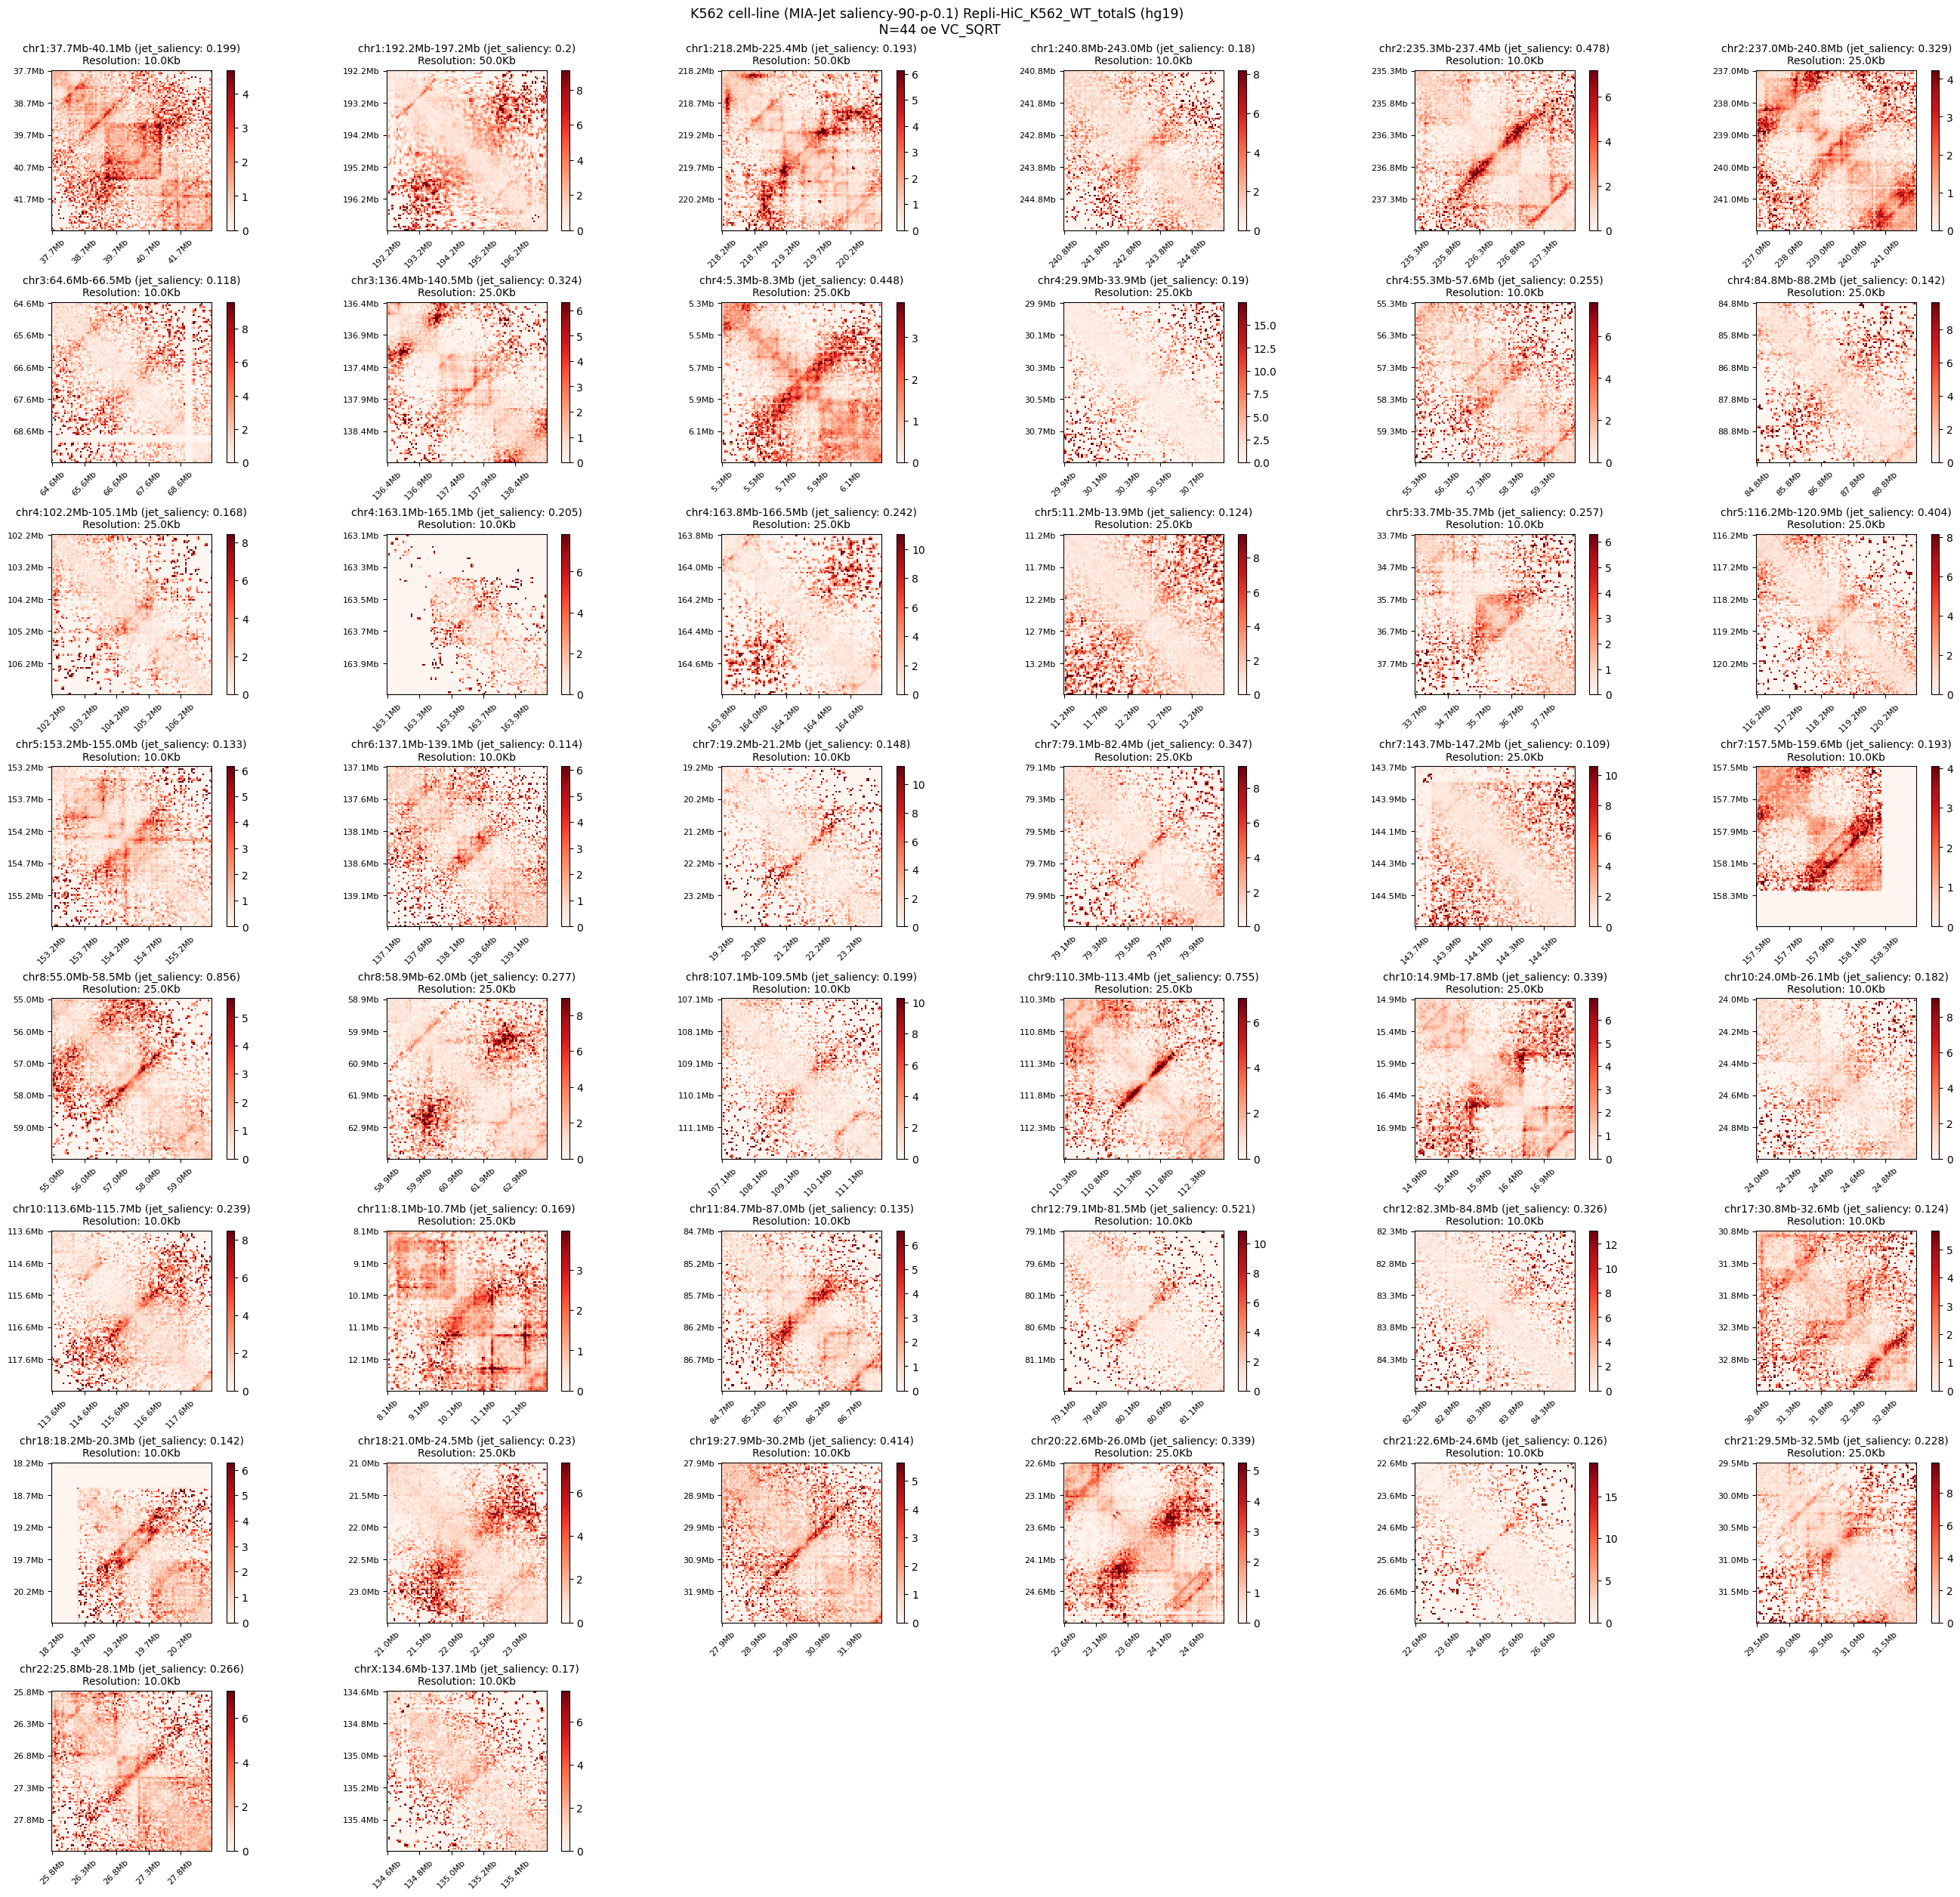

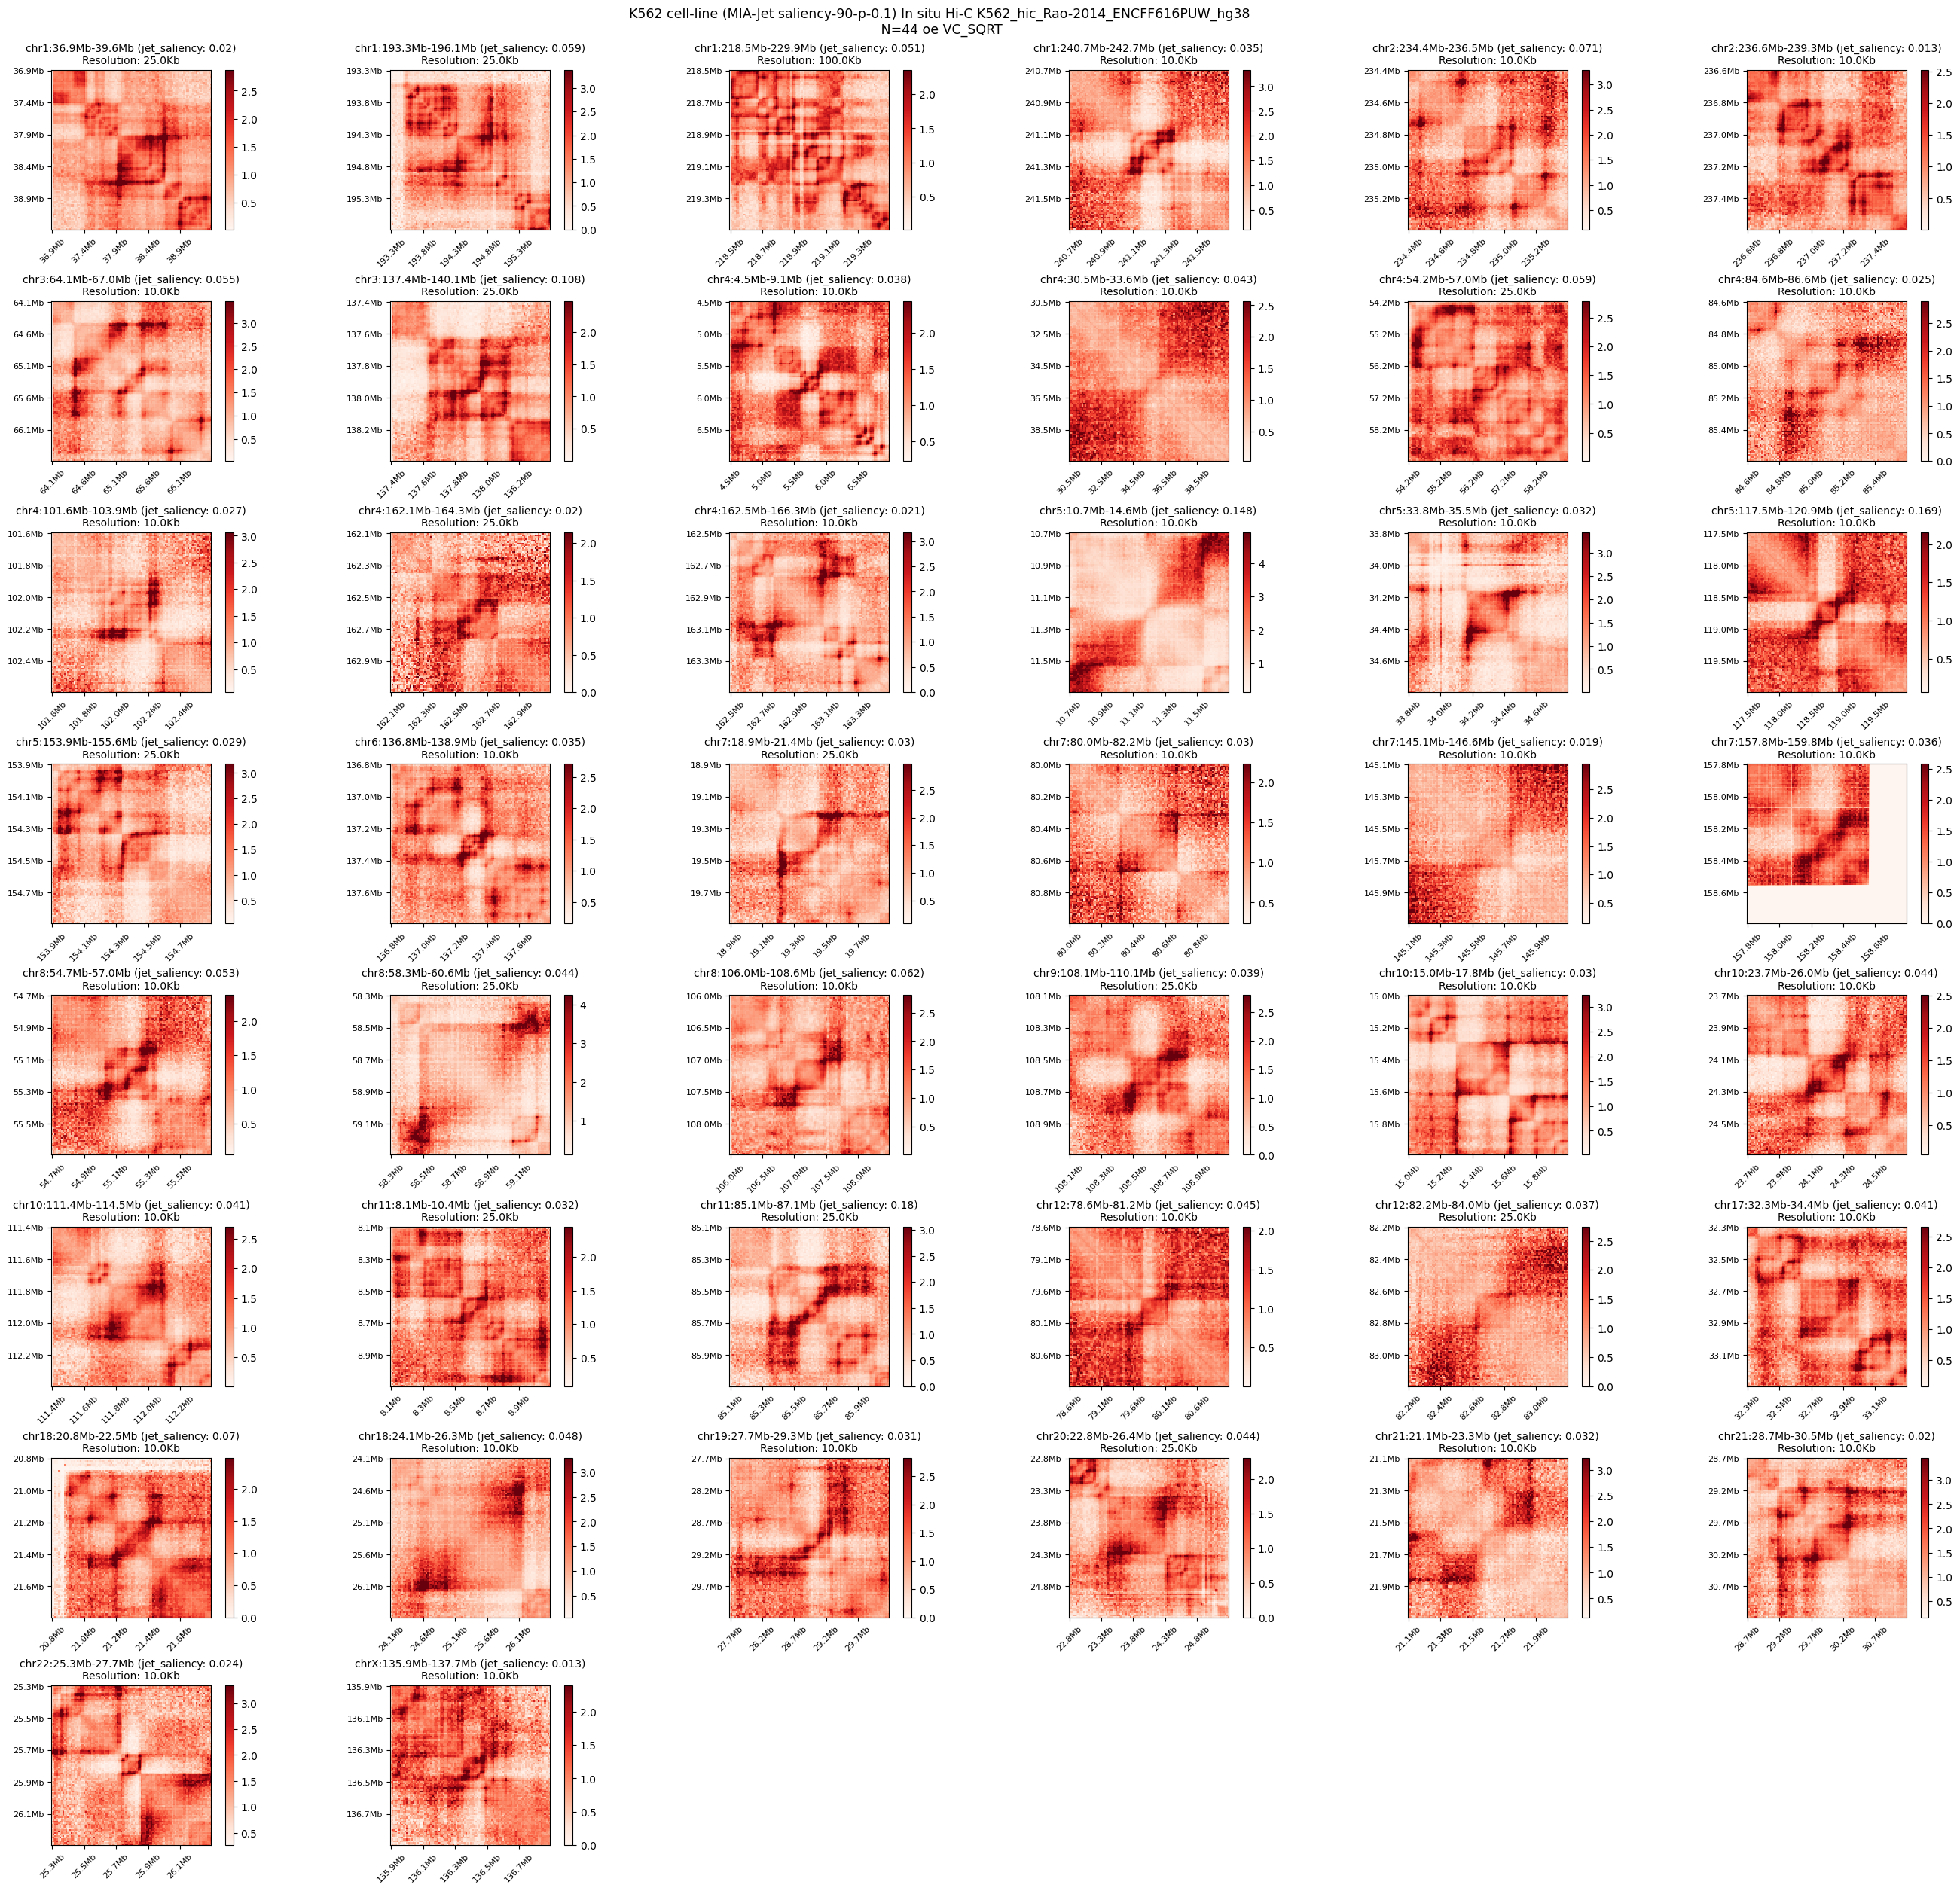

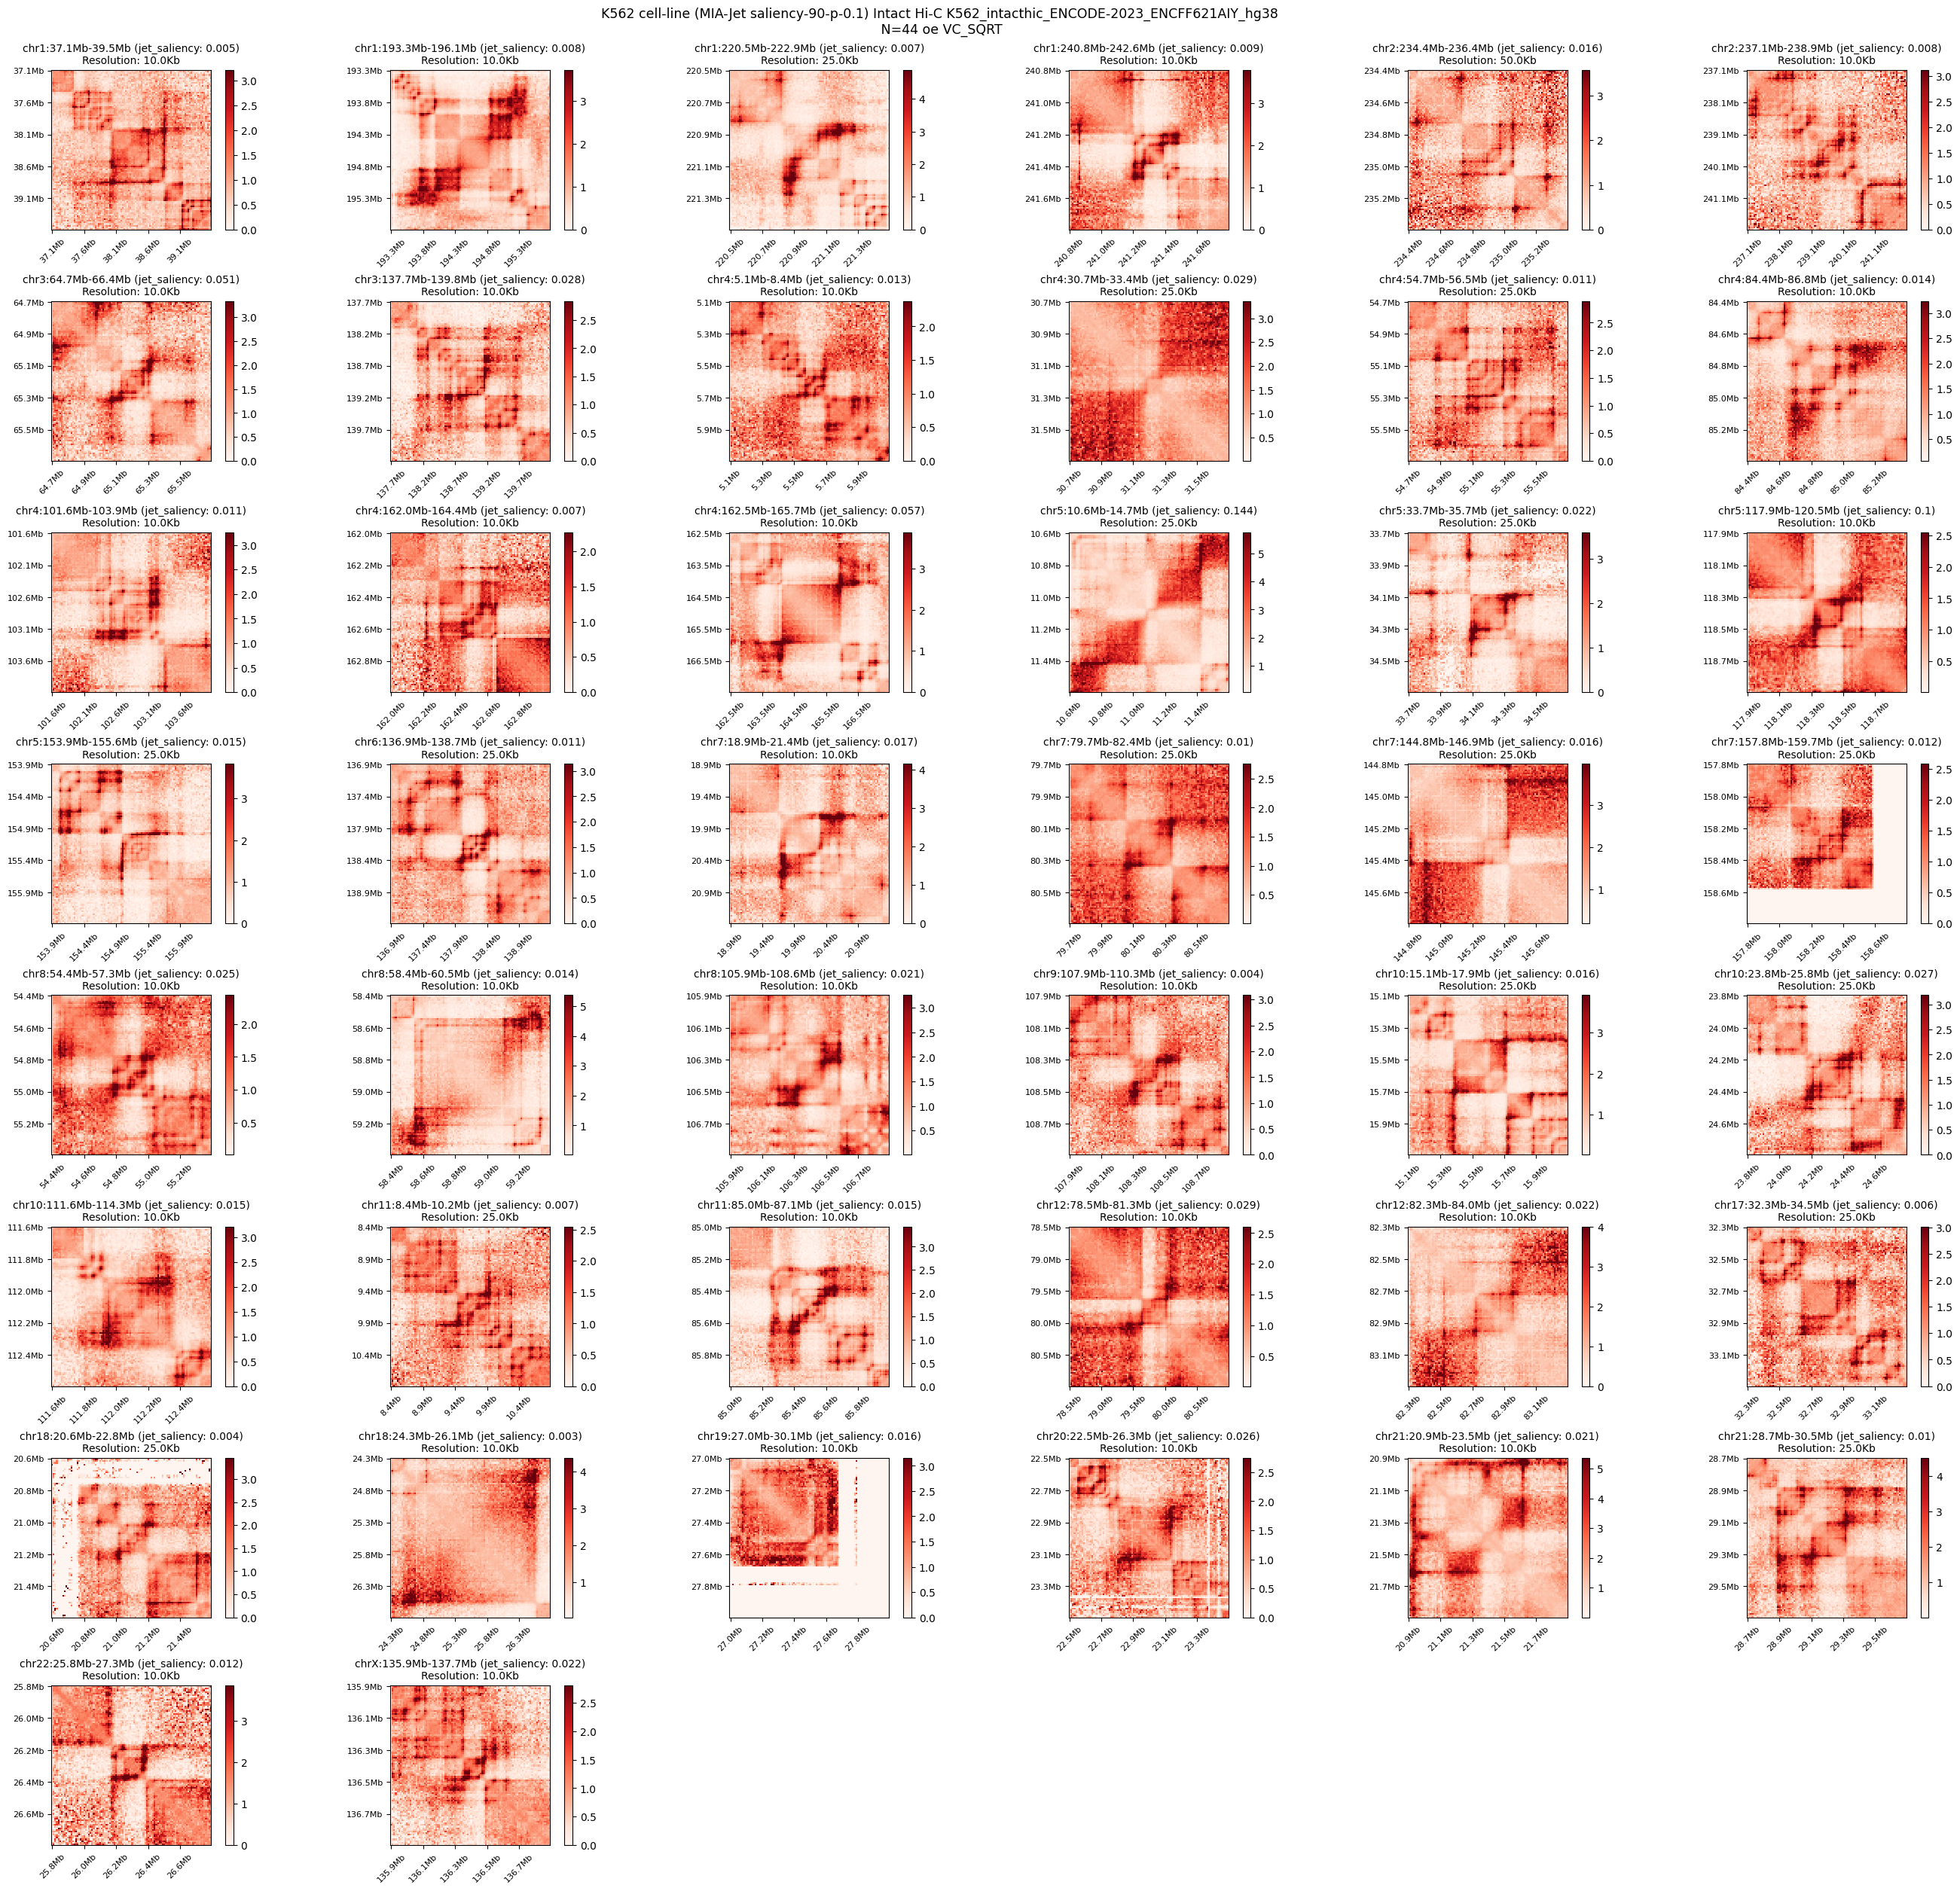

In [36]:
# PLOT COMMON JETS
for idx in range(len(names)):
    
    suptitle = names[idx]

    key_df = common[suptitle]

    sampled_df_stack = df_stack[idx].loc[df_stack[idx]["unique_id"].isin(key_df)]
    indices = sampled_df_stack.index

    sampled_stack = stacks[idx][indices]

    titles = sampled_df_stack["chrom"].astype(str) + ":" + sampled_df_stack["start"].apply(lambda x : genomic_labels(x, N=1)) + "-" + sampled_df_stack["end"].apply(lambda x : genomic_labels(x, N=1))
    titles += f" ({ranking_col[select_method_idx]}: " + sampled_df_stack[ranking_col[select_method_idx]].map(lambda x : f"{x:.3g}") + ")"
    titles += f"\nResolution: " + pd.Series([genomic_labels(r, N=1) for r in resolutions[idx]]).astype(str) 
    titles = titles.tolist()

    genomic_shift = sampled_df_stack["start"].to_numpy()

    vmaxes = [np.percentile(s, 99) for s in sampled_stack]


    plot_n_hic(sampled_stack, 
            titles=titles, 
            resolution=resolutions[idx],
            suptitle=f"{data_name} {suptitle}\n N={len(common)} {data_type} {normalization}", 
            show=True, 
            genomic_shift=genomic_shift, 
            cmap_label=None, 
            vmax=vmaxes,
            ppr=6,
            savepath=f"{save_path}/{data_name}_individual-common_{data_type}_{names[idx]}.png",
            cmap="Reds")

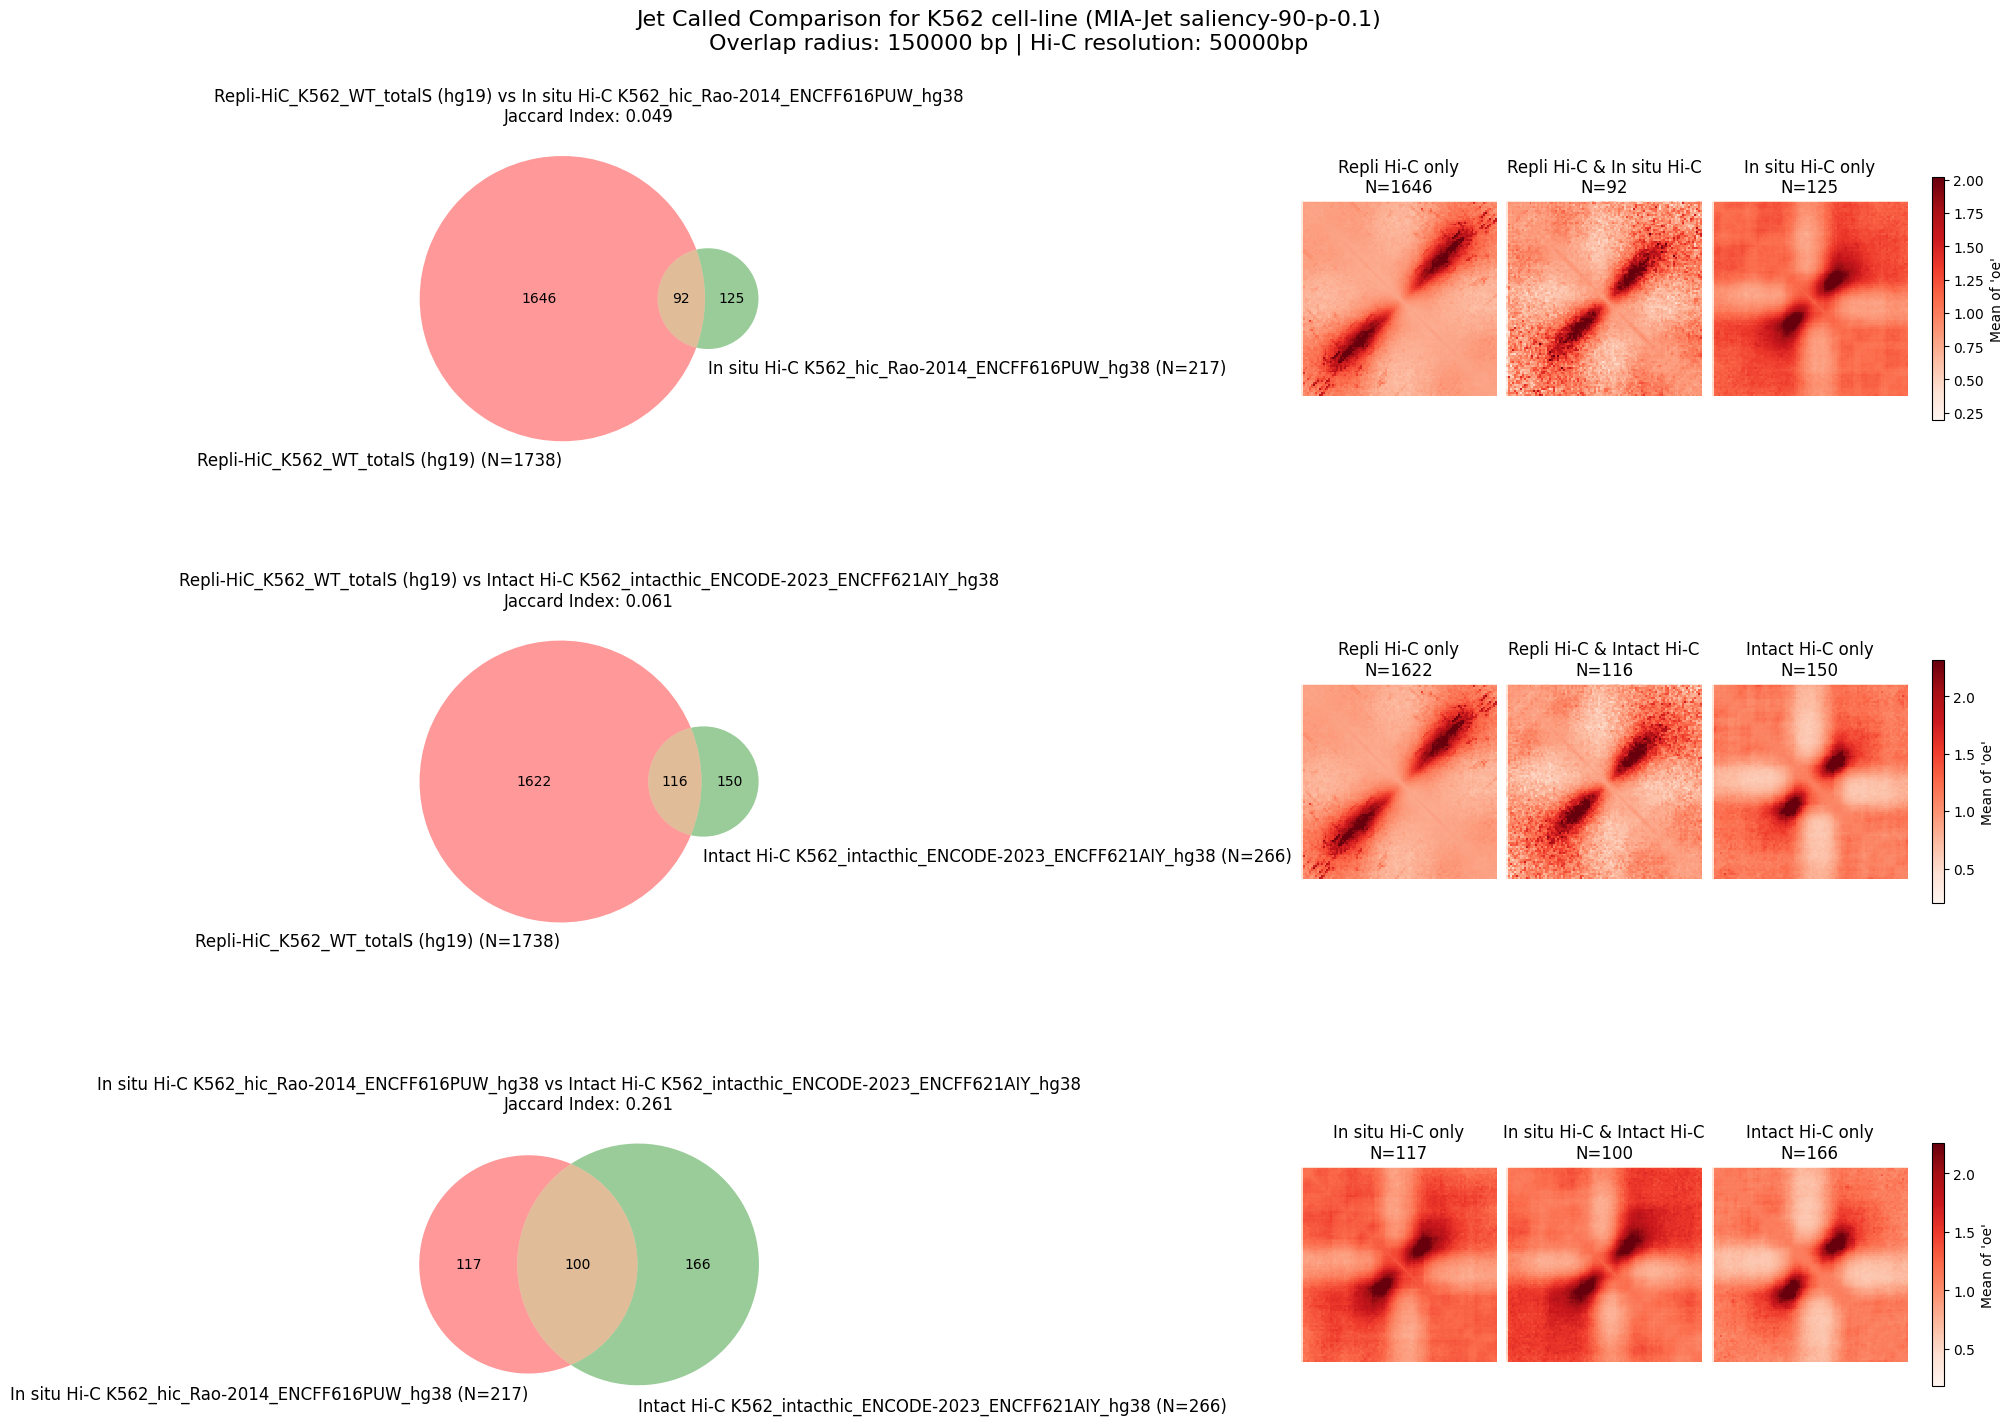

In [34]:
# PLOT VENN DIAGRAM
pairs = list(itertools.combinations(names, 2))
num_pairs = len(pairs)

fig, axes = plt.subplots(num_pairs, 4, figsize=(5*4, 5*num_pairs), layout='constrained', width_ratios=[2, 1, 1, 1])

for row, (A, B) in enumerate(pairs):
    # compute overlaps as before
    total_A = results.loc[A, A]
    total_B = results.loc[B, B]
    inter = results.loc[A, B]
    only_A = total_A - inter
    only_B = total_B - inter

    # column 0: the Venn
    ax = axes[row, 0]
    venn2(subsets=(int(only_A), int(only_B), int(inter)),
        set_labels=(f"{A} (N={int(total_A)})", f"{B} (N={int(total_B)})"),
        ax=ax)
    ax.set_title(f"{A} vs {B}\nJaccard Index: {inter / (inter + only_A + only_B):.3f}")

    # columns 1–3: the three imshows
    # agg_map_pairs.shape == (n_pairs, 3, H, W)
    A_idx = names.index(A)
    B_idx = names.index(B)
    A_abbrev = names_abbrev[A_idx]
    B_abbrev = names_abbrev[B_idx]
    titles = [f"{A_abbrev} only", f"{A_abbrev} & {B_abbrev}", f"{B_abbrev} only"]
    counts = [int(only_A), int(inter), int(only_B)]
    row_imgs = agg_map_pairs[row]
    row_vmax = max(np.percentile(img, 99) for img in row_imgs)
    for col_idx in range(3):
        ax = axes[row, col_idx+1]
        img = agg_map_pairs[row, col_idx]
        im = ax.imshow(img, cmap="Reds", interpolation="none", vmax=np.percentile(img, 99))
        ax.set_title(f"{titles[col_idx]}\nN={counts[col_idx]}")
        ax.axis('off')
    fig.colorbar(im, ax=axes[row, 1:], fraction=0.02, pad=0.04, label=f"Mean of '{data_type}'")


fig.suptitle(f"Jet Called Comparison for {data_name}\nOverlap radius: {int(buffer_radius)} bp | Hi-C resolution: {resolution}bp", fontsize=16)

plt.savefig(f"{save_path}/{data_name}_venn_diagram-agg.png", dpi=300)

plt.show()


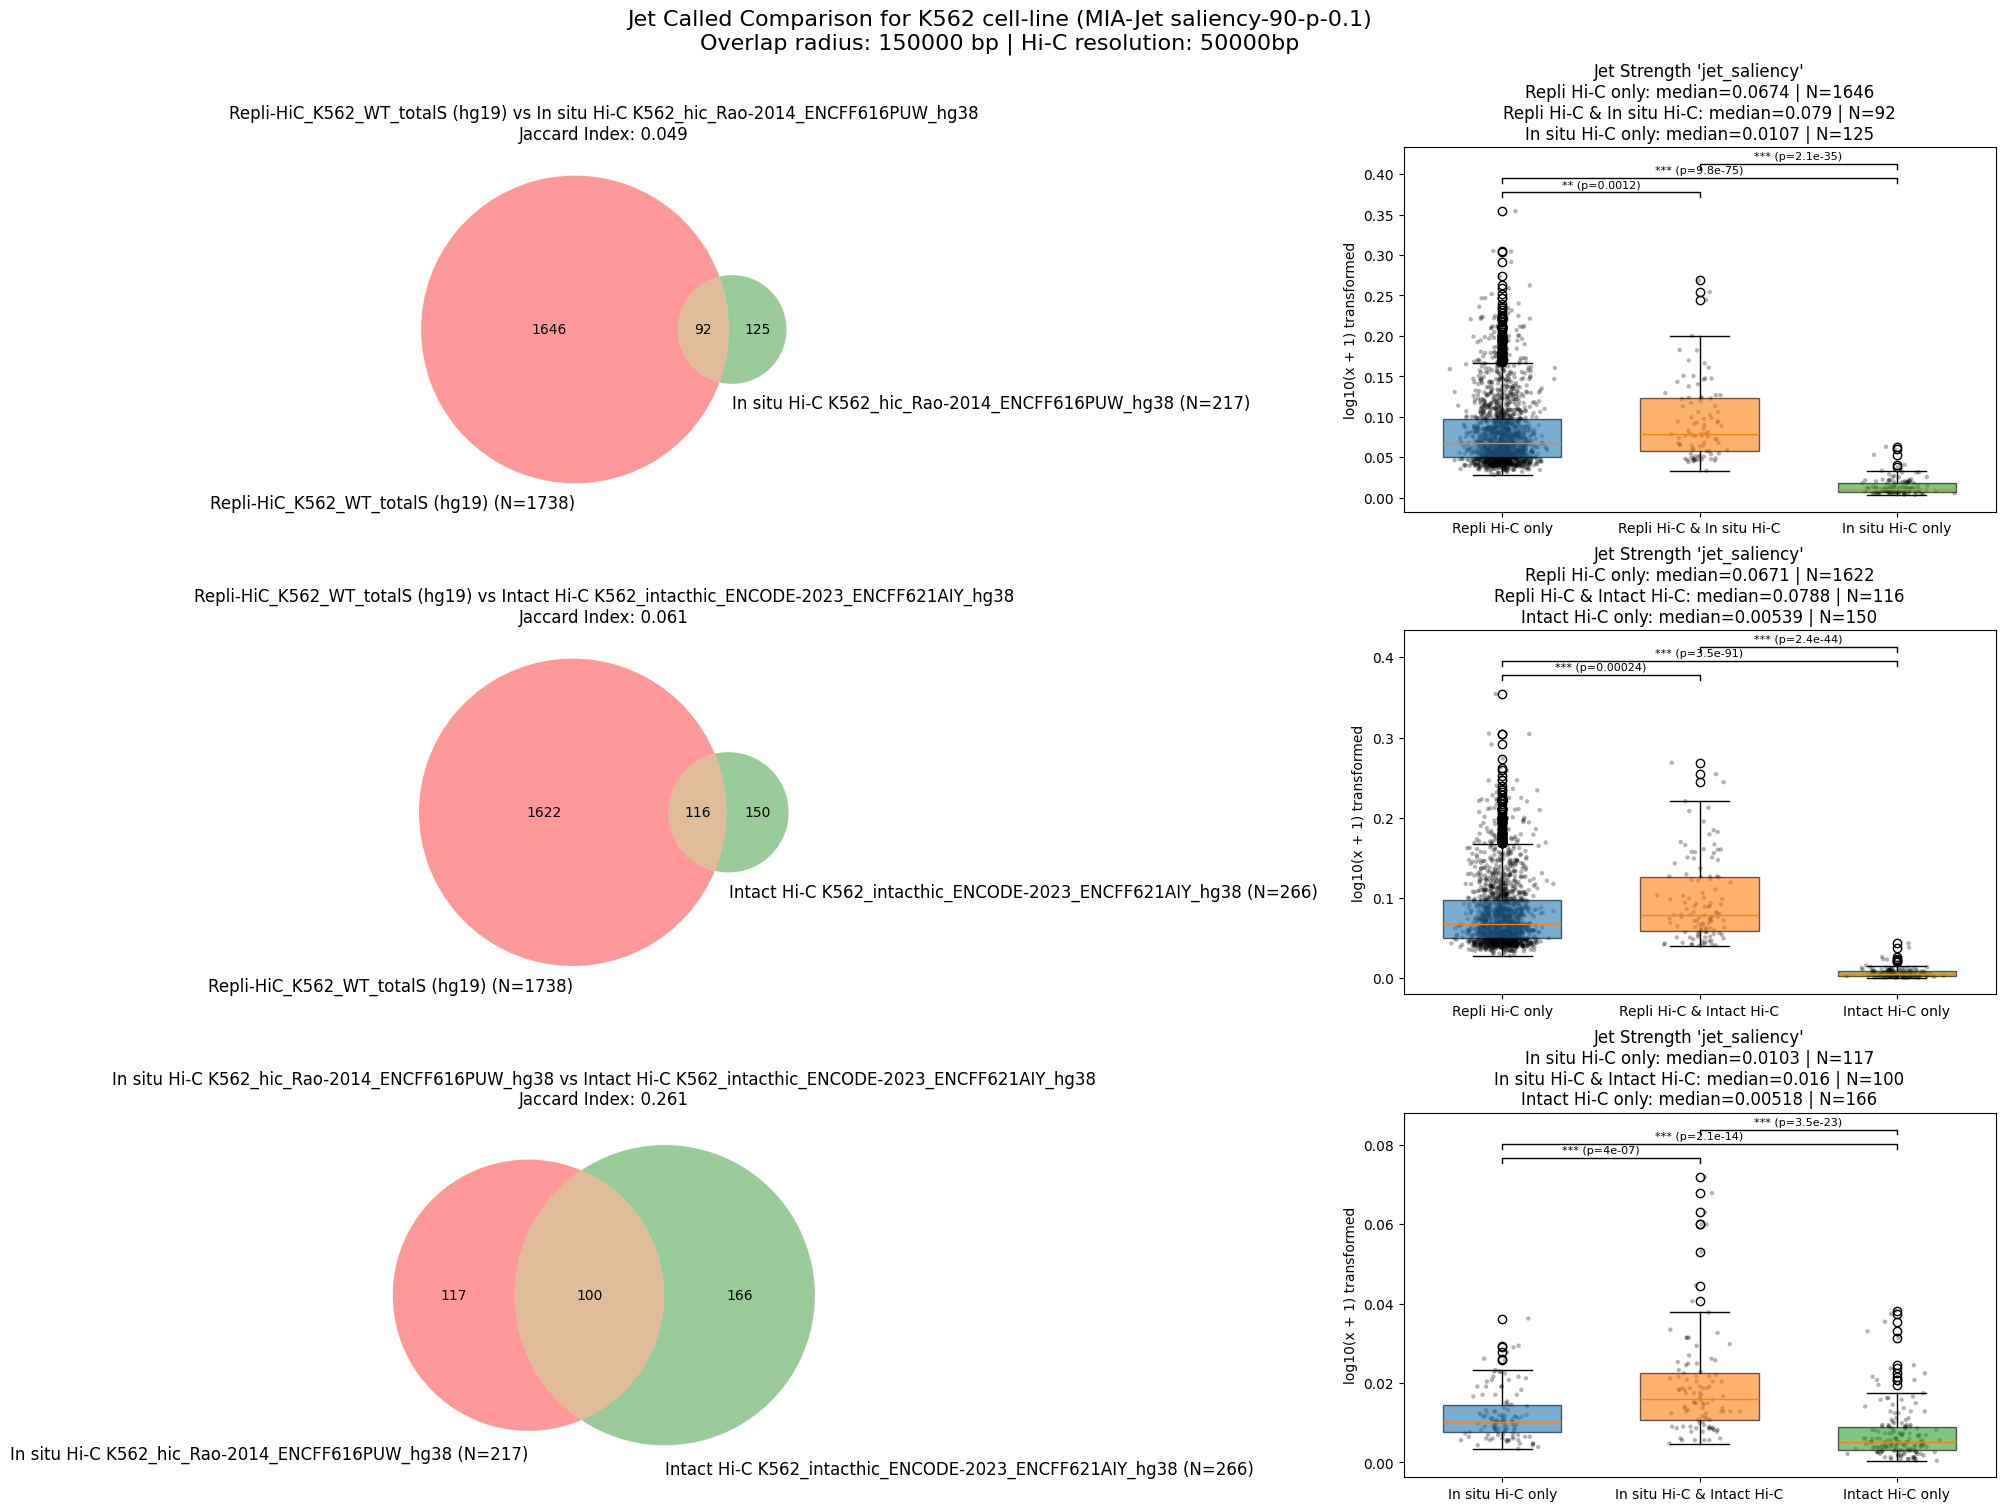

In [35]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# PLOT VENN DIAGRAM
pairs = list(itertools.combinations(names, 2))
num_pairs = len(pairs)

fig, axes = plt.subplots(num_pairs, 2, figsize=(5*4, 5*num_pairs), layout='constrained', width_ratios=[2, 1])

for row, (A, B) in enumerate(pairs):
    # compute overlaps as before
    total_A = results.loc[A, A]
    total_B = results.loc[B, B]
    inter = results.loc[A, B]
    only_A = total_A - inter
    only_B = total_B - inter

    # column 0: the Venn
    ax = axes[row, 0]
    venn2(subsets=(int(only_A), int(only_B), int(inter)),
        set_labels=(f"{A} (N={int(total_A)})", f"{B} (N={int(total_B)})"),
        ax=ax)
    ax.set_title(f"{A} vs {B}\nJaccard Index: {inter / (inter + only_A + only_B):.3f}")

    # columns 1–3: the three imshows
    # agg_map_pairs.shape == (n_pairs, 3, H, W)
    A_idx = names.index(A)
    B_idx = names.index(B)
    A_abbrev = names_abbrev[A_idx]
    B_abbrev = names_abbrev[B_idx]
    titles = [f"{A_abbrev} only", f"{A_abbrev} & {B_abbrev}", f"{B_abbrev} only"]
    counts = [int(only_A), int(inter), int(only_B)]

    # Instead of 3 columns, plot just one boxplot but side by side
    ax = axes[row, 1]

    # boxplot specific variables
    positions = np.arange(1, 4) # 4-1=3 because A only, intersection, B only
    points = jet_strength_pairs[row]
    points = [np.clip(vals, 0, None) for vals in points]
    points = [np.log10(x + 1) for x in points]

    add_pairwise_sig(ax, positions, points)

    bp = ax.boxplot(points, patch_artist=True, positions=positions, widths=0.6)

    # color each box
    for patch, col in zip(bp['boxes'], colors[:3]):
        patch.set_facecolor(col)
        patch.set_alpha(0.6)

    # jittered scatter on top
    for j, vals in enumerate(points):
        y = np.array(vals)
        x = np.full_like(y, positions[j], dtype=float) + np.random.normal(0, 0.08, size=len(y))
        ax.scatter(x, y, alpha=0.3, s=10, color='k', edgecolor='none')

    title_boxstat = title_boxplot(f"Jet Strength '{ranking_col[select_method_idx]}'", titles, points)
    ax.set_title(title_boxstat)

    # x-tick labels
    ax.set_xticks(positions)
    ax.set_xticklabels(titles, rotation=0)

    ax.set_ylabel("log10(x + 1) transformed")


fig.suptitle(f"Jet Called Comparison for {data_name}\nOverlap radius: {int(buffer_radius)} bp | Hi-C resolution: {resolution}bp", fontsize=16)

plt.savefig(f"{save_path}/{data_name}_venn_diagram-jetstrength.png", dpi=300)

plt.show()
